In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df= pd.read_csv(r'D:\Ecommerce-Sales-Intelligence\data\cleaned_retail_data.csv', parse_dates=['invoicedate'])

In [6]:
# ─── RFM SEGMENTATION ────────────────────────────────────────────────────────
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)

rfm = (df.groupby('customer_id')
         .agg(
             recency=('invoicedate', lambda x: (snapshot_date - x.max()).days),
             frequency=('invoice', 'nunique'),
             monetary=('total_revenue', 'sum')
         )
         .reset_index())

# Score each dimension into quintiles (1-5)
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

# Segment mapping
def rfm_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 1 and f >= 4:
        return "Can't Lose Them"
    elif r <= 1 and f <= 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)


In [7]:
# Segment summary
segment_summary = (rfm.groupby('segment')
                      .agg(customers=('customer_id', 'count'),
                           avg_recency=('recency', 'mean'),
                           avg_frequency=('frequency', 'mean'),
                           avg_monetary=('monetary', 'mean'),
                           total_revenue=('monetary', 'sum'))
                      .sort_values('total_revenue', ascending=False)
                      .reset_index())

print("\n🎯 RFM SEGMENT SUMMARY")
print(segment_summary.to_string(index=False))


🎯 RFM SEGMENT SUMMARY
            segment  customers  avg_recency  avg_frequency  avg_monetary  total_revenue
          Champions       1300    19.967692      17.089231   9329.319665   12128115.565
    Loyal Customers       1403    71.389879       5.419102   1934.398251    2713960.746
            At Risk        824   369.100728       4.940534   1982.979966    1633975.492
    Needs Attention       1290   339.805426       1.351163    442.733504     571126.220
      New Customers        443    28.106095       1.460497    890.832077     394638.610
               Lost        513   568.226121       1.000000    345.374273     177177.002
Potential Loyalists        105   103.542857       1.676190   1185.100410     124435.543


In [9]:
# Custom colors
BLUE   = "#2563EB"
GREEN  = "#16A34A"
RED    = "#DC2626"
ORANGE = "#EA580C"
GRAY   = "#6B7280"

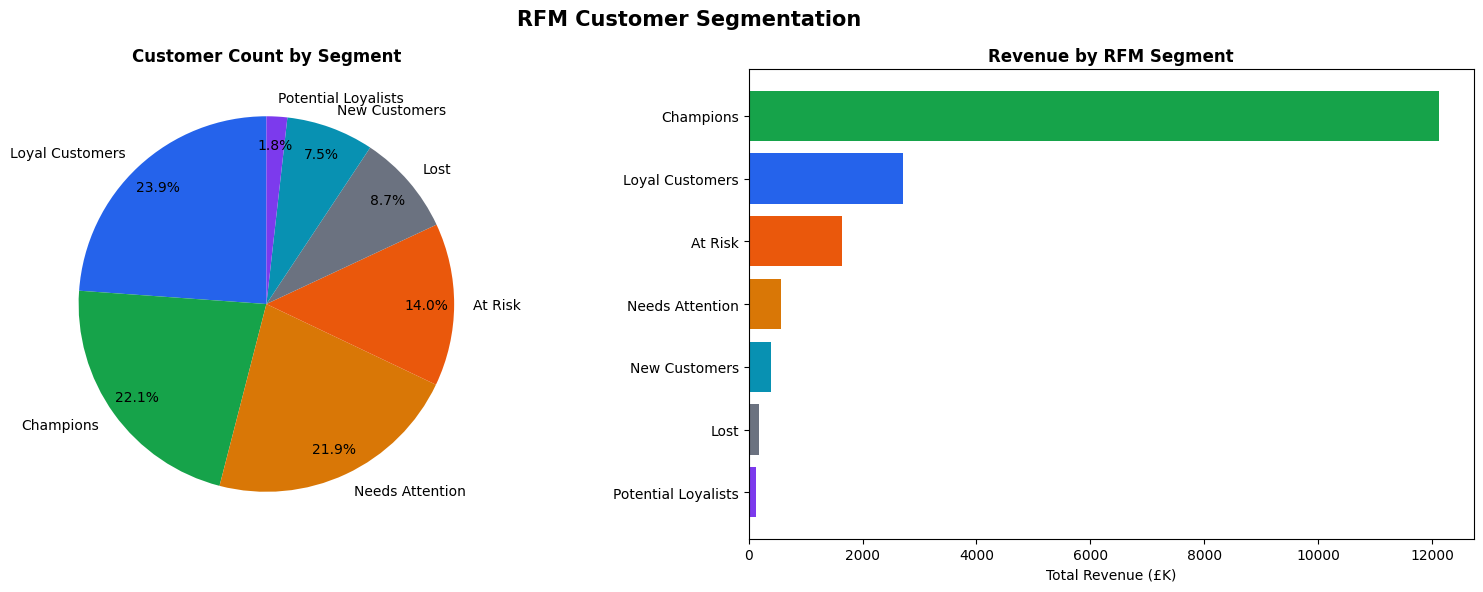

✅ RFM data saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_colors = {
    'Champions': '#16A34A',
    'Loyal Customers': '#2563EB',
    'Potential Loyalists': '#7C3AED',
    'New Customers': '#0891B2',
    'Needs Attention': '#D97706',
    'At Risk': '#EA580C',
    "Can't Lose Them": '#DC2626',
    'Lost': '#6B7280'
}

seg_counts = rfm['segment'].value_counts()
colors_list = [segment_colors.get(s, GRAY) for s in seg_counts.index]

axes[0].pie(seg_counts.values, labels=seg_counts.index,
            colors=colors_list, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[0].set_title('Customer Count by Segment', fontweight='bold')

seg_rev = segment_summary.set_index('segment')['total_revenue'].sort_values()
colors_rev = [segment_colors.get(s, GRAY) for s in seg_rev.index]
axes[1].barh(seg_rev.index, seg_rev.values / 1000, color=colors_rev)
axes[1].set_xlabel('Total Revenue (£K)')
axes[1].set_title('Revenue by RFM Segment', fontweight='bold')

plt.suptitle('RFM Customer Segmentation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\Ecommerce-Sales-Intelligence\outputs/07_rfm_segmentation.png', bbox_inches='tight')
plt.show()

rfm.to_csv(r'D:\Ecommerce-Sales-Intelligence\data/rfm_segments.csv', index=False)
print("✅ RFM data saved.")

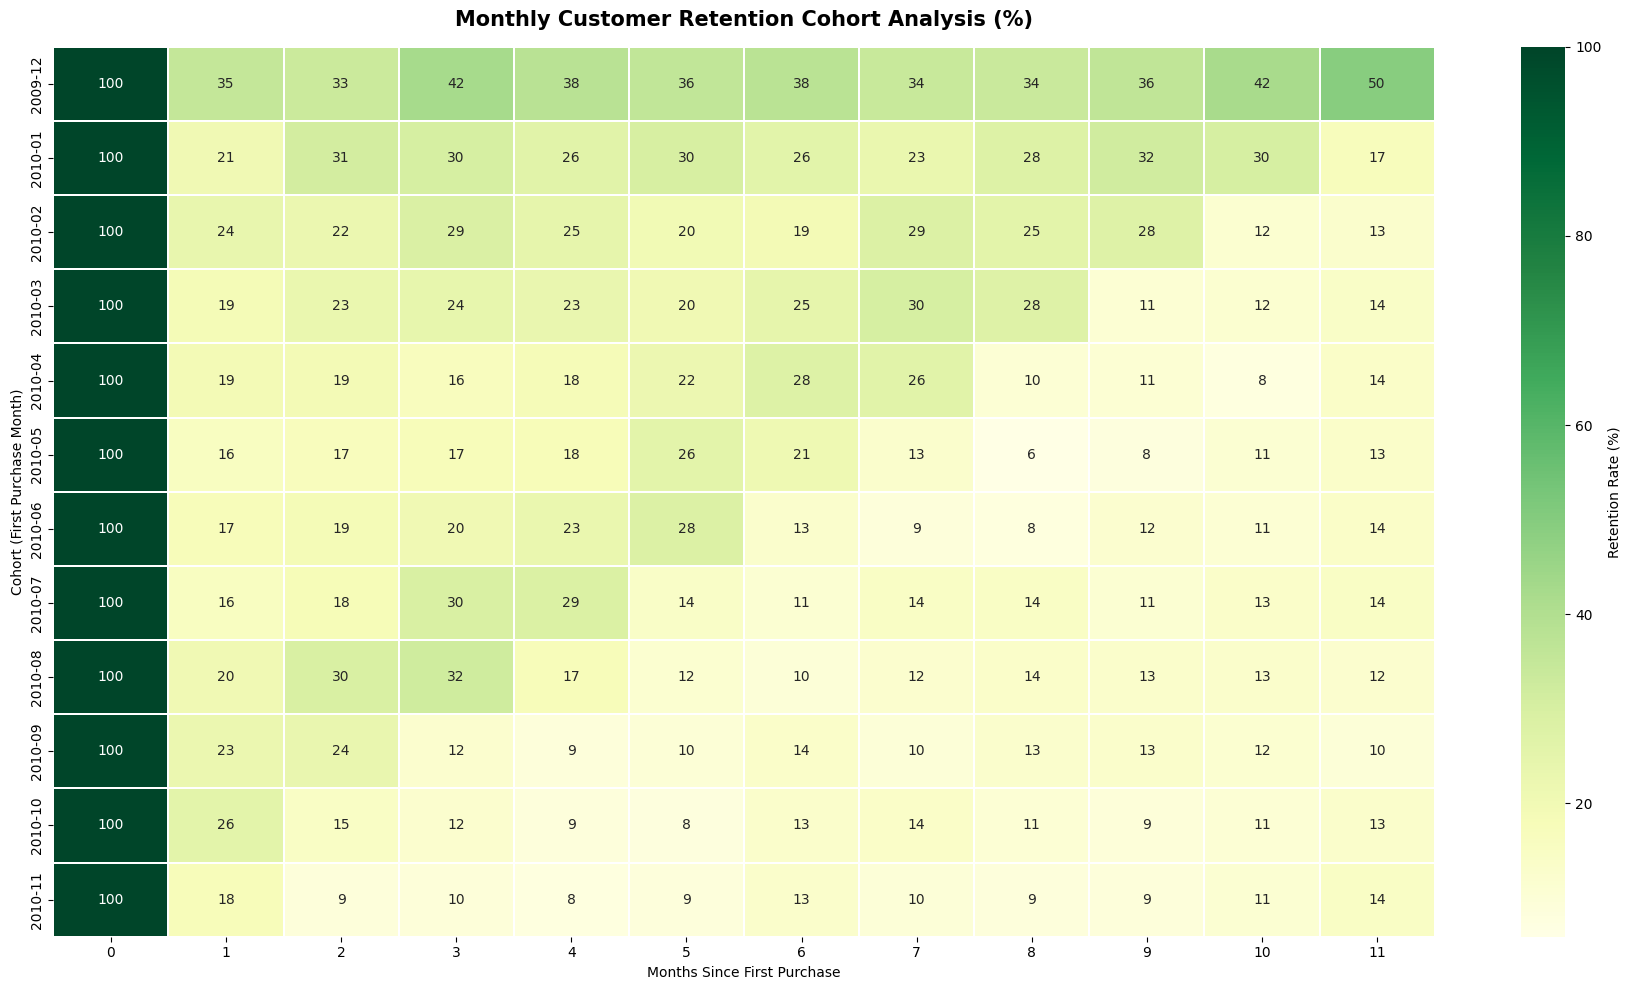

✅ All EDA charts saved.


In [16]:
#Cohort Retention Heatmap 
df['cohort_month'] = (df.groupby('customer_id')['invoicedate']
                        .transform('min')
                        .dt.to_period('M'))
df['purchase_month'] = df['invoicedate'].dt.to_period('M')
df['cohort_index'] = ((df['purchase_month'] - df['cohort_month'])
                        .apply(lambda x: x.n))

cohort_data = (df.groupby(['cohort_month', 'cohort_index'])['customer_id']
                 .nunique()
                 .reset_index())
cohort_pivot = cohort_data.pivot(index='cohort_month',
                                  columns='cohort_index',
                                  values='customer_id')
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(retention.iloc[:12, :12],  # First 12 cohorts × 12 months
            annot=True, fmt='.0f', cmap='YlGn',
            ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Retention Rate (%)'})
ax.set_title('Monthly Customer Retention Cohort Analysis (%)',
             fontweight='bold', fontsize=15, pad=15)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig('D:\\Ecommerce-Sales-Intelligence\\outputs/08_cohort_retention.png', bbox_inches='tight')
plt.show()
print("✅ All EDA charts saved.")